## Dataset Information

Investors are considering making an investment in a new form of transportation - JetRail. JetRail uses Jet propulsion technology to run rails and move people at a high speed! While JetRail has mastered the technology and they hold the patent for their product, the investment would only make sense, if they can get more than 1 Million monthly users with in next 18 months.
 
You need to help Unicorn ventures with the decision. They usually invest in B2C start-ups less than 4 years old looking for pre-series A funding. In order to help Unicorn Ventures in their decision, you need to forecast the traffic on JetRail for the next 7 months.

## Import modules

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from fbprophet import Prophet

In [ ]:
# !pip install fbprophet
# install visual c++ - visual studio
# if you face errors - use conda install

## Loading the dataset

In [3]:
df = pd.read_csv('Traffic data.csv')
df.head()

,ID,Datetime,Count
0,0,25-08-2012 00:00,8
1,1,25-08-2012 01:00,2
2,2,25-08-2012 02:00,6
3,3,25-08-2012 03:00,2
4,4,25-08-2012 04:00,2


In [4]:
df

,ID,Datetime,Count
0,0,25-08-2012 00:00,8
1,1,25-08-2012 01:00,2
2,2,25-08-2012 02:00,6
3,3,25-08-2012 03:00,2
4,4,25-08-2012 04:00,2
...,...,...,...
18283,18283,25-09-2014 19:00,868
18284,18284,25-09-2014 20:00,732
18285,18285,25-09-2014 21:00,702
18286,18286,25-09-2014 22:00,580


## Preprocessing the dataset

In [5]:
# check null values
df.isnull().sum()

ID          0
Datetime    0
Count       0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18288 entries, 0 to 18287
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ID        18288 non-null  int64 
 1   Datetime  18288 non-null  object
 2   Count     18288 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 428.8+ KB


In [7]:
# convert object to datetime datatype
df['Datetime'] = pd.to_datetime(df['Datetime'], format='%d-%m-%Y %H:%M')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18288 entries, 0 to 18287
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   ID        18288 non-null  int64         
 1   Datetime  18288 non-null  datetime64[ns]
 2   Count     18288 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 428.8 KB


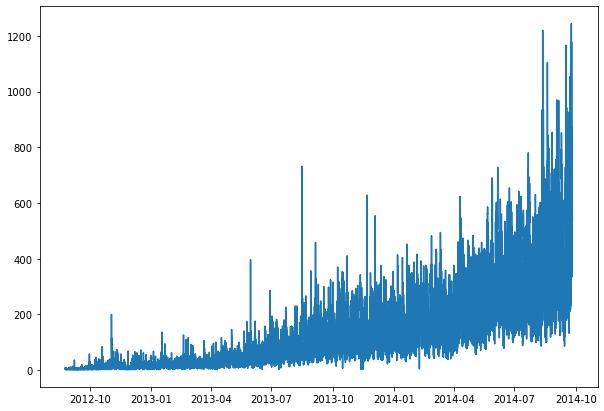

In [9]:
# EDA
plt.figure(figsize=(10,7))
plt.plot(df['Datetime'], df['Count'])
plt.show()

## Format data for the model

In [10]:
df.index = df['Datetime']
df['y'] = df['Count']
df.drop(columns=['ID', 'Datetime', 'Count'], axis=1, inplace=True)
df = df.resample('D').sum()
df.head()

,y
Datetime,
2012-08-25,76
2012-08-26,88
2012-08-27,62
2012-08-28,58
2012-08-29,60


In [11]:
df['ds'] = df.index
df.head()

,y,ds
Datetime,,
2012-08-25,76,2012-08-25
2012-08-26,88,2012-08-26
2012-08-27,62,2012-08-27
2012-08-28,58,2012-08-28
2012-08-29,60,2012-08-29


## Input Split

In [12]:
size = 60
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=size/len(df), shuffle=False)

In [13]:
train.tail()

,y,ds
Datetime,,
2014-07-23,10130,2014-07-23
2014-07-24,8156,2014-07-24
2014-07-25,7192,2014-07-25
2014-07-26,6562,2014-07-26
2014-07-27,6094,2014-07-27


In [14]:
test.head()

,y,ds
Datetime,,
2014-07-28,8546,2014-07-28
2014-07-29,8218,2014-07-29
2014-07-30,8498,2014-07-30
2014-07-31,8740,2014-07-31
2014-08-01,9186,2014-08-01


In [17]:
test.tail()

,y,ds
Datetime,,
2014-09-21,9102,2014-09-21
2014-09-22,14116,2014-09-22
2014-09-23,13304,2014-09-23
2014-09-24,16856,2014-09-24
2014-09-25,14152,2014-09-25


## Model Training

---## Standardized ML Pipeline*Auto-generated by Phase 5 ML Standardization***STEP 1** — LazyPredict baseline comparison  **STEP 2** — PyCaret automated pipeline

### STEP 1 — LazyPredict: Baseline Model ComparisonRun all sklearn-compatible models to find the best baseline.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from lazypredict.Supervised import LazyRegressor

# Use existing train/test split from preprocessing above
# Ensure numeric-only for LazyPredict (handles mixed types)
try:
    X_train_lp = X_train.select_dtypes(include=['number']).fillna(0)
    X_test_lp = X_test.select_dtypes(include=['number']).fillna(0)
except AttributeError:
    X_train_lp, X_test_lp = X_train, X_test

# Run LazyPredict
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models_df, predictions_df = reg.fit(X_train_lp, X_test_lp, y_train, y_test)

print("=" * 60)
print("LazyPredict — Regression Baseline Results")
print("=" * 60)
models_df

#### Top Models Visualization

In [ ]:
import matplotlib.pyplot as plt

top_n = min(15, len(models_df))
fig, ax = plt.subplots(figsize=(10, 6))
models_df['R-Squared'].head(top_n).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('R-Squared')
ax.set_title(f'Top {top_n} Models — R-Squared')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### STEP 2 — PyCaret: Automated ML PipelineFull pipeline with automated preprocessing, model comparison, tuning, and finalization.> **Note:** PyCaret requires Python 3.9–3.11. Install with: `pip install pycaret`

In [ ]:
import sys

# PyCaret setup
try:
    from pycaret.regression import setup, compare_models, finalize_model, predict_model, save_model, plot_model
except ImportError:
    print("PyCaret not installed. Install with: pip install pycaret")
    print("Requires Python 3.9-3.11")
    raise SystemExit("PyCaret required for STEP 2")

# Configure PyCaret session
reg_setup = setup(
    data=df,
    target='ID',
    session_id=42,
    verbose=False,
    fold=5,
)
print("PyCaret setup complete.")

In [ ]:
# Compare all models
best_model = compare_models(sort='R2', n_select=1)
print(f"\nBest model: {best_model}")

In [ ]:
# Finalize the best model (retrain on full dataset)
final_model = finalize_model(best_model)
print(f"Finalized model: {final_model}")

#### Model Evaluation

In [ ]:
# Model evaluation plots
try:
    plot_model(best_model, plot='residuals', save=True)
    plot_model(best_model, plot='error', save=True)
    plot_model(best_model, plot='feature', save=True)
except Exception as e:
    print(f"Plot generation note: {e}")

#### Save Model Pipeline

In [ ]:
# Save the final pipeline
save_model(final_model, 'final_model_pipeline')
print("Model saved as 'final_model_pipeline.pkl'")